In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
       # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<h2>Becoming familiar with the data</h2>

In [2]:
#importing dependencies
import tensorflow as tf
from tensorflow.keras import models

2026-05-04 22:03:18.646882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777932199.006196      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777932199.106706      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777932199.964513      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777932199.964561      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777932199.964564      57 computation_placer.cc:177] computation placer alr

<h3>Image Dimensions</h3>

In [3]:
batch_size = 32
img_height = 224
img_width  = 224

In [4]:
train_data_dir = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
test_data_dir = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

In [5]:
IMG_SIZE = (224 , 224)

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(directory=train_data_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode="categorical", # what type are the labels?
                                                                            batch_size=32) # batch_size is 32 by default, this is generally a good number
test_ds = tf.keras.preprocessing.image_dataset_from_directory(directory=test_data_dir,
                                                                           image_size=IMG_SIZE,
                                                                           label_mode="categorical", batch_size=32)

Found 14034 files belonging to 6 classes.


I0000 00:00:1777932273.661831      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3000 files belonging to 6 classes.


In [7]:
class_names =train_ds.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


<h1>visualizing the data</h1>

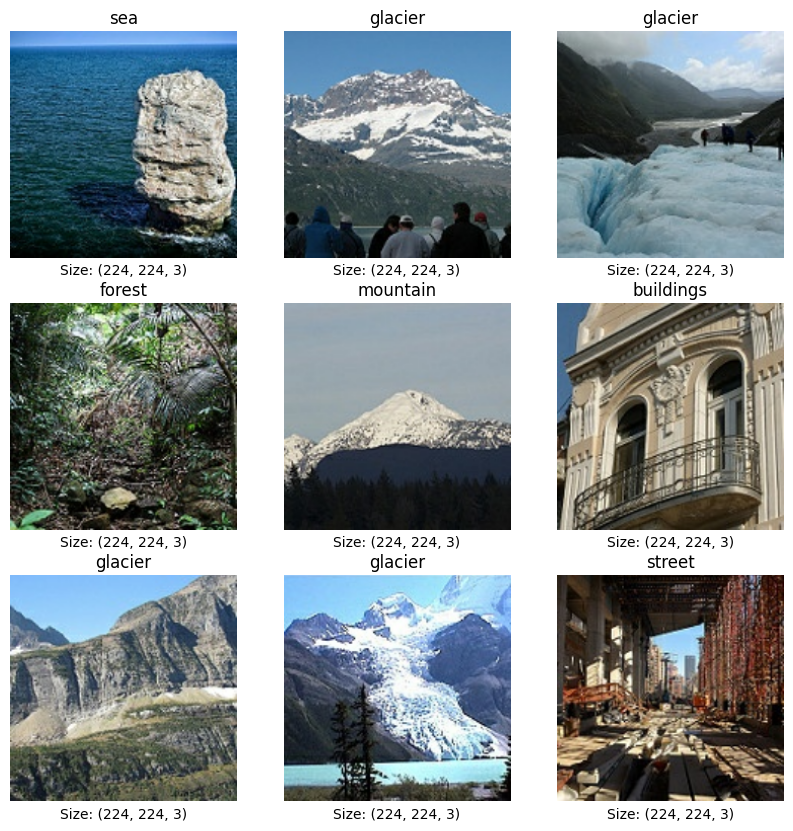

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.xlabel(f"Size: {images[i].shape}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

<h3>doing some normalization </h3>

In [9]:
for images, labels in test_ds.take(1):
    print(images[0])
    print(labels[4])
    

tf.Tensor(
[[[16.         14.          1.        ]
  [19.53125    18.540178    6.0446424 ]
  [20.214285   20.040178    9.258928  ]
  ...
  [11.         12.174103    0.        ]
  [ 7.0356445   8.035645    0.        ]
  [ 3.          4.          0.        ]]

 [[15.495536   13.495536    0.49553573]
  [19.28127    17.781229    5.285694  ]
  [20.126453   19.11908     8.337831  ]
  ...
  [16.855406   18.358316    7.0399923 ]
  [ 9.593928   11.0983925   3.817197  ]
  [ 1.4866072   2.9910715   0.        ]]

 [[15.696428   13.522322    0.1741072 ]
  [19.55648    17.470203    4.7142854 ]
  [20.35808    18.5625      7.5768294 ]
  ...
  [24.941244   26.767141   17.803556  ]
  [12.106934   14.020656    8.269468  ]
  [ 0.          1.8258928   0.        ]]

 ...

 [[ 0.          0.17410278  0.        ]
  [ 0.          0.17410278  0.        ]
  [ 0.          0.14379025  0.        ]
  ...
  [ 6.856209    7.856209    2.575164  ]
  [ 6.5814223   8.224306    1.3509109 ]
  [ 7.2187195   9.870514    1.044

In [10]:
import numpy as np

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
normalized_test_ds = test_ds.map(lambda z,f: (normalization_layer(z),f))
image_batch, labels_batch = next(iter(normalized_test_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

print(labels_batch)

0.0 0.9974613
tf.Tensor(
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]], shape=(32, 6), dtype=float32)


<h1>Importing the Resnet Archeticture</h1>

In [12]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50

# 1. Create base model with tf.keras.applications
base_model = ResNet50(include_top=False , weights = 'imagenet')

base_model.trainable = True

# 3. Freeze everything up to the last 10 layers
# This says: freeze every layer UNTIL the 10th-to-last one
for layer in base_model.layers[:-10]:
    layer.trainable = False

inputs = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")

x = base_model(inputs)

print(f"Shape after base_model: {x.shape}")

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"After GlobalAveragePooling2D(): {x.shape}")

outputs = tf.keras.layers.Dense(6, activation="softmax", name="output_layer")(x)

model_01 = tf.keras.Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Shape after base_model: (None, 7, 7, 2048)
After GlobalAveragePooling2D(): (None, 2048)


<h4>Compiling & Fitting the Model</h4>

In [13]:
Testimages , Testlabels = next(iter(normalized_test_ds))
print(Testlabels[2])

tf.Tensor([1. 0. 0. 0. 0. 0.], shape=(6,), dtype=float32)


In [14]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model_weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Callback to adjust (reduce) learning rate when improvement slows down
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       # Multiply the LR by 0.2 (e.g., 0.001 becomes 0.0002)
    patience=3,       # Wait 3 epochs before reducing
    min_lr=1e-7,      # Don't let it go below this value
    verbose=1
)

# 3. Compile (I recommend starting with a slightly lower LR for ResNet fine-tuning)
model_01.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    metrics=['accuracy']
)

# 4. Fit with callbacks
history_01 = model_01.fit(
    normalized_train_ds,
    epochs=25,
    validation_data=normalized_test_ds,
    steps_per_epoch=len(normalized_train_ds),
    callbacks=[checkpoint_callback, reduce_lr_callback] # Add them here
)

Epoch 1/25


I0000 00:00:1777932337.786290     135 service.cc:152] XLA service 0x798ea8004490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777932337.786338     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777932339.990245     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.1875 - loss: 1.7831 

I0000 00:00:1777932345.855414     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5600 - loss: 1.0904
Epoch 1: val_accuracy improved from -inf to 0.15567, saving model to best_model_weights.h5


...

439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8320 - loss: 0.4554 - val_accuracy: 0.7973 - val_loss: 0.5752 - learning_rate: 4.0000e-05
Epoch 11/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8387 - loss: 0.4428
Epoch 11: val_accuracy did not improve from 0.79733
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8387 - loss: 0.4427 - val_accuracy: 0.7830 - val_loss: 0.6045 - learning_rate: 4.0000e-05
Epoch 12/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8407 - loss: 0.4394
Epoch 12: val_accuracy did not improve from 0.79733
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8407 - loss: 0.4394 - val_accuracy: 0.7857 - val_loss: 0.6041 - learning_rate: 4.0000e-05
Epoch 13/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8435 - loss: 0.4291
Epoch 13: val_accuracy did not improve from 0.79733

Epoch 13: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8435

439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8502 - loss: 0.4170 - val_accuracy: 0.8000 - val_loss: 0.5700 - learning_rate: 8.0000e-06
Epoch 15/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8517 - loss: 0.4118
Epoch 15: val_accuracy improved from 0.80000 to 0.80067, saving model to best_model_weights.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8518 - loss: 0.4117 - val_accuracy: 0.8007 - val_loss: 0.5713 - learning_rate: 8.0000e-06
Epoch 16/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8547 - loss: 0.4132
Epoch 16: val_accuracy improved from 0.80067 to 0.80200, saving model to best_model_weights.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8547 - loss: 0.4131 - val_accuracy: 0.8020 - val_loss: 0.5700 - learning_rate: 8.0000e-06
Epoch 17/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8470 - loss: 0.4174
Epoch 17: val_accuracy did not improve from 0.80200

Epoch 17: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8471 - loss: 0.4173 - val_accuracy: 0.8017 - val_loss: 0.5709 - learning_rate: 8.0000e-06
Epoch 18/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8534 - loss: 0.4058
Epoch 18: val_accuracy improved from 0.80200 to 0.80233, saving model to best_model_weights.h5


439/439 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8534 - loss: 0.4057 - val_accuracy: 0.8023 - val_loss: 0.5715 - learning_rate: 1.6000e-06
Epoch 19/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8565 - loss: 0.4058
Epoch 19: val_accuracy did not improve from 0.80233
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.8565 - loss: 0.4057 - val_accuracy: 0.8017 - val_loss: 0.5712 - learning_rate: 1.6000e-06
Epoch 20/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8536 - loss: 0.4062
Epoch 20: val_accuracy did not improve from 0.80233

Epoch 20: ReduceLROnPlateau reducing learning rate to 3.200000264769187e-07.
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8537 - loss: 0.4062 - val_accuracy: 0.8020 - val_loss: 0.5715 - learning_rate: 1.6000e-06
Epoch 21/25
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8576 - loss: 0.3984
Epoch 21: val_accuracy did not improve from 0.80233
439/439 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8576

<h3>Loading the Best Saved Model Weights</h3>

In [15]:
model_01.load_weights('best_model_weights.h5')
print("✅ Best model weights loaded successfully from 'best_model_weights.h5'")

✅ Best model weights loaded successfully from 'best_model_weights.h5'


<h2>Evaluating the model</h2>

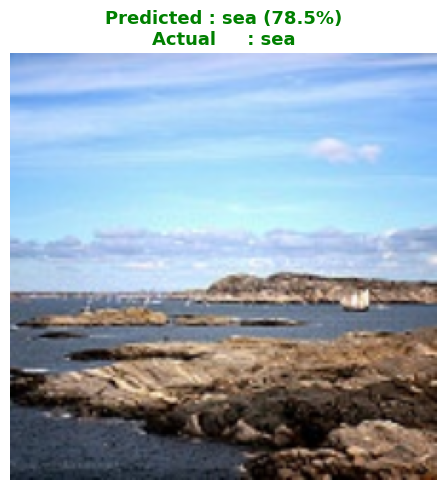

In [31]:
# ============================================================
# Evaluation: Random Image from Validation Set
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# Pick a random batch from the test set
image_batch, label_batch = next(iter(normalized_test_ds))

# Pick a random index within the batch
random_idx = random.randint(0, len(image_batch) - 1)
random_image  = image_batch[random_idx]
actual_label  = class_names[np.argmax(label_batch[random_idx])]

# Run prediction (model expects a batch, so expand dims)
pred = model_01.predict(tf.expand_dims(random_image, axis=0), verbose=0)
predicted_label = class_names[np.argmax(pred)]
confidence      = np.max(pred) * 100

# Display
plt.figure(figsize=(5, 5))
plt.imshow(random_image)
plt.axis('off')

color = "green" if predicted_label == actual_label else "red"
plt.title(
    f"Predicted : {predicted_label} ({confidence:.1f}%)\nActual     : {actual_label}",
    fontsize=13,
    color=color,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

<h2>Test with your own Personal Data</h2>

📊 Class Probabilities:
  buildings     93.3%  █████████████████████████████████████
  forest         0.6%  
  glacier        0.4%  
  mountain       1.2%  
  sea            1.7%  
  street         2.8%  █


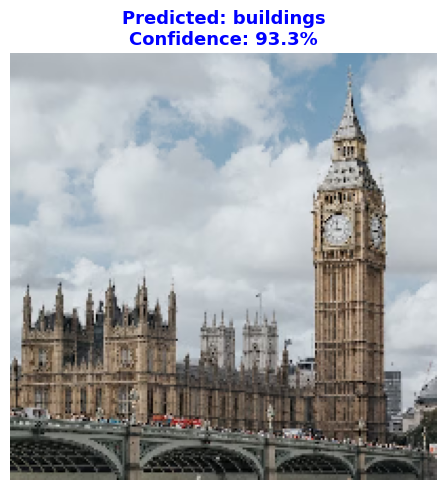

In [83]:
# ============================================================
# Test the Model with Your Own Image
# ============================================================

from tensorflow.keras.preprocessing import image as keras_image

def predict_custom_image(img_path):
    """
    Load a personal image, preprocess it, and predict its class.
    
    Args:
        img_path (str): Path to your image file (jpg, png, etc.)
    """
    # Load & resize to match model input
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)       # shape: (224, 224, 3)
    img_array = img_array / 255.0                   # normalize to [0, 1]
    img_array = tf.expand_dims(img_array, axis=0)   # shape: (1, 224, 224, 3)
    
    # Predict
    predictions = model_01.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence      = np.max(predictions) * 100

    # Show all class probabilities
    print("📊 Class Probabilities:")
    for cls, prob in zip(class_names, predictions[0]):
        bar = "█" * int(prob * 40)
        print(f"  {cls:<12} {prob*100:5.1f}%  {bar}")

    # Display image with prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(keras_image.load_img(img_path, target_size=(224, 224)))
    plt.axis('off')
    plt.title(
        f"Predicted: {predicted_class}\nConfidence: {confidence:.1f}%",
        fontsize=13,
        color='blue',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


#CHANGE THIS PATH TO YOUR IMAGE
predict_custom_image('/kaggle/input/datasets/kareemehab1k/random-images-from-the-internet/InternetImages (1).avif')

<h3>Evaluation metrices</h3>

In [84]:
# ============================================================
# Evaluation Metrics - Classification Report
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect all true labels and predictions from the test set
y_true = []
y_pred = []

for image_batch, label_batch in normalized_test_ds:
    # Get true labels
    y_true.extend(np.argmax(label_batch.numpy(), axis=1))
    
    # Get predictions
    preds = model_01.predict(image_batch, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print classification report
print("📊 Classification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

📊 Classification Report:
              precision    recall  f1-score   support

   buildings       0.81      0.80      0.81       437
      forest       0.94      0.95      0.94       474
     glacier       0.74      0.74      0.74       553
    mountain       0.72      0.74      0.73       525
         sea       0.79      0.76      0.77       510
      street       0.85      0.83      0.84       501

    accuracy                           0.80      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.80      0.80      0.80      3000



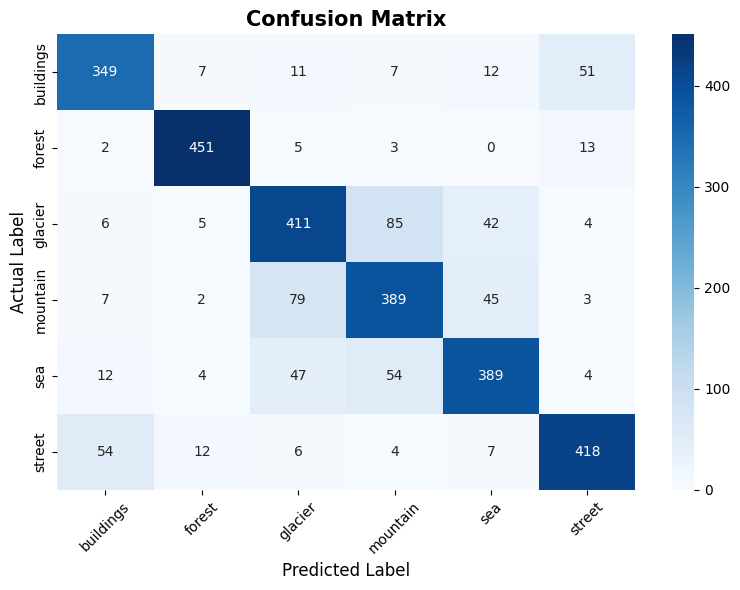

In [85]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

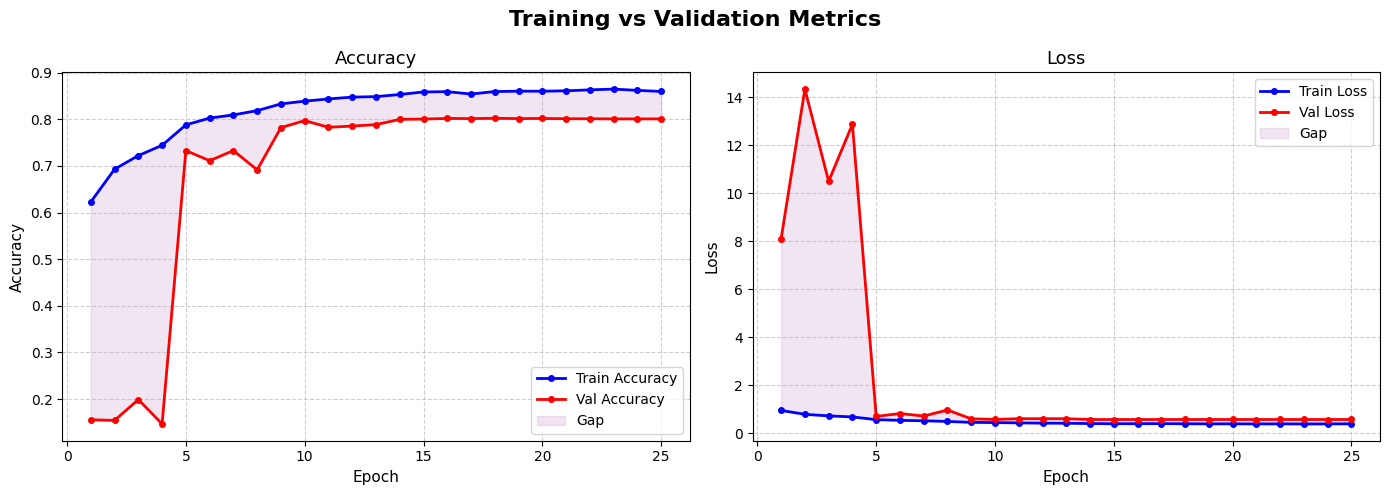

In [86]:
# ============================================================
# Training vs Validation - Accuracy & Loss Curves
# ============================================================

epochs_range = range(1, len(history_01.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Validation Metrics', fontsize=16, fontweight='bold')

# --- Accuracy Plot ---
axes[0].plot(epochs_range, history_01.history['accuracy'],
             'b-o', linewidth=2, markersize=4, label='Train Accuracy')
axes[0].plot(epochs_range, history_01.history['val_accuracy'],
             'r-o', linewidth=2, markersize=4, label='Val Accuracy')
axes[0].fill_between(epochs_range,
                     history_01.history['accuracy'],
                     history_01.history['val_accuracy'],
                     alpha=0.1, color='purple', label='Gap')
axes[0].set_title('Accuracy',  fontsize=13)
axes[0].set_xlabel('Epoch',    fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Loss Plot ---
axes[1].plot(epochs_range, history_01.history['loss'],
             'b-o', linewidth=2, markersize=4, label='Train Loss')
axes[1].plot(epochs_range, history_01.history['val_loss'],
             'r-o', linewidth=2, markersize=4, label='Val Loss')
axes[1].fill_between(epochs_range,
                     history_01.history['loss'],
                     history_01.history['val_loss'],
                     alpha=0.1, color='purple', label='Gap')
axes[1].set_title('Loss',   fontsize=13)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss',  fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# Final Summary
# ============================================================

best_epoch      = np.argmax(history_01.history['val_accuracy']) + 1
best_val_acc    = np.max(history_01.history['val_accuracy'])   * 100
final_train_acc = history_01.history['accuracy'][-1]           * 100
final_val_acc   = history_01.history['val_accuracy'][-1]       * 100
final_train_loss= history_01.history['loss'][-1]
final_val_loss  = history_01.history['val_loss'][-1]
overfit_gap     = final_train_acc - final_val_acc

print("=" * 45)
print("          📋 FINAL TRAINING SUMMARY")
print("=" * 45)
print(f"  Best Epoch          : Epoch {best_epoch}")
print(f"  Best Val Accuracy   : {best_val_acc:.2f}%")
print(f"  Final Train Accuracy: {final_train_acc:.2f}%")
print(f"  Final Val Accuracy  : {final_val_acc:.2f}%")
print(f"  Final Train Loss    : {final_train_loss:.4f}")
print(f"  Final Val Loss      : {final_val_loss:.4f}")
print("-" * 45)
print(f"  Overfitting Gap     : {overfit_gap:.2f}%", end=" ")

if overfit_gap < 3:
    print("✅ No overfitting")
elif overfit_gap < 8:
    print("⚠️  Slight overfitting")
else:
    print("❌ Overfitting detected")
print("=" * 45)

          📋 FINAL TRAINING SUMMARY
  Best Epoch          : Epoch 18
  Best Val Accuracy   : 80.23%
  Final Train Accuracy: 85.98%
  Final Val Accuracy  : 80.10%
  Final Train Loss    : 0.3910
  Final Val Loss      : 0.5714
---------------------------------------------
  Overfitting Gap     : 5.88% ⚠️  Slight overfitting
